In [2]:
import pandas as pd
data = pd.read_csv("Food_Delivery_Time_Prediction.csv")

In [3]:
print(data.head())

  Order_ID       Customer_Location     Restaurant_Location  Distance  \
0  ORD0001  (17.030479, 79.743077)  (12.358515, 85.100083)      1.57   
1  ORD0002  (15.398319, 86.639122)  (14.174874, 77.025606)     21.32   
2  ORD0003  (15.687342, 83.888808)  (19.594748, 82.048482)      6.95   
3  ORD0004  (20.415599, 78.046984)  (16.915906, 78.278698)     13.79   
4  ORD0005  (14.786904, 78.706532)  (15.206038, 86.203182)      6.72   

  Weather_Conditions Traffic_Conditions  Delivery_Person_Experience  \
0              Rainy             Medium                           4   
1             Cloudy             Medium                           8   
2              Snowy             Medium                           9   
3             Cloudy                Low                           2   
4              Rainy               High                           6   

  Order_Priority Order_Time Vehicle_Type  Restaurant_Rating  Customer_Rating  \
0         Medium  Afternoon          Car                4.1 

In [4]:
print(data.isna().sum())

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64


In [5]:
#drop useless columns
data = data.drop(['Order_ID','Customer_Location','Restaurant_Location'],axis=1)

#encoding
data = pd.get_dummies(data, drop_first= True)


In [6]:
#scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
cols =['Distance', 'Restaurant_Rating', 'Order_Cost','Tip_Amount','Customer_Rating','Delivery_Person_Experience']

data[cols] = sc.fit_transform(data[cols])


In [7]:
print("Mean of Delivery Person Experience: ",data['Delivery_Person_Experience'].mean(),"\nMean of Customer_Rating: ",data['Customer_Rating'].mean())
print("Median of Tip_Amount: ",data['Tip_Amount'].median())
print("Mode of Order_Cost: ",data['Order_Cost'].mode())

Mean of Delivery Person Experience:  4.440892098500626e-18 
Mean of Customer_Rating:  4.529709940470639e-16
Median of Tip_Amount:  0.031184903153901558
Mode of Order_Cost:  0    1.401256
Name: Order_Cost, dtype: float64


In [8]:
print(data['Order_Cost'].value_counts().idxmax())

1.401255869563944


In [9]:
#select numeric columns
numeric_data = data.select_dtypes(include=['int64','float64'])

#compute correlation 
corr_matrix = numeric_data.corr()
print(corr_matrix)

                            Distance  Delivery_Person_Experience  \
Distance                    1.000000                    0.017562   
Delivery_Person_Experience  0.017562                    1.000000   
Restaurant_Rating           0.064676                   -0.004492   
Customer_Rating             0.003430                   -0.122447   
Delivery_Time              -0.075143                   -0.019098   
Order_Cost                 -0.022275                    0.061015   
Tip_Amount                 -0.006466                   -0.069218   

                            Restaurant_Rating  Customer_Rating  Delivery_Time  \
Distance                             0.064676         0.003430      -0.075143   
Delivery_Person_Experience          -0.004492        -0.122447      -0.019098   
Restaurant_Rating                    1.000000         0.101661      -0.091855   
Customer_Rating                      0.101661         1.000000      -0.021952   
Delivery_Time                       -0.091855     

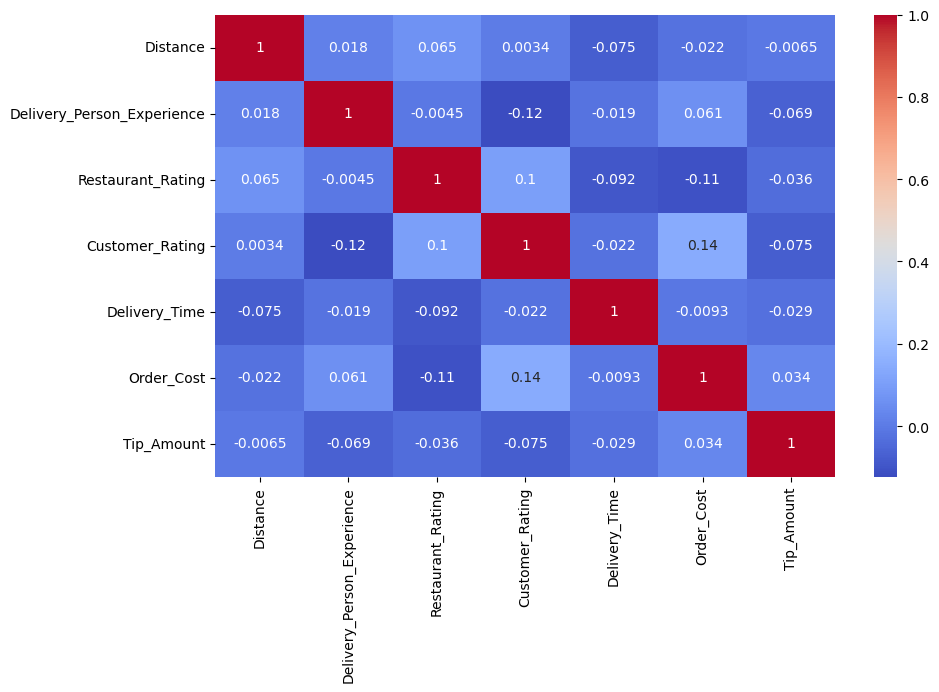

In [10]:
#visualize with heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm')
plt.show()

In [11]:
#correlation with target
corr_matrix['Delivery_Time'].sort_values(ascending=False)

Delivery_Time                 1.000000
Order_Cost                   -0.009307
Delivery_Person_Experience   -0.019098
Customer_Rating              -0.021952
Tip_Amount                   -0.029154
Distance                     -0.075143
Restaurant_Rating            -0.091855
Name: Delivery_Time, dtype: float64

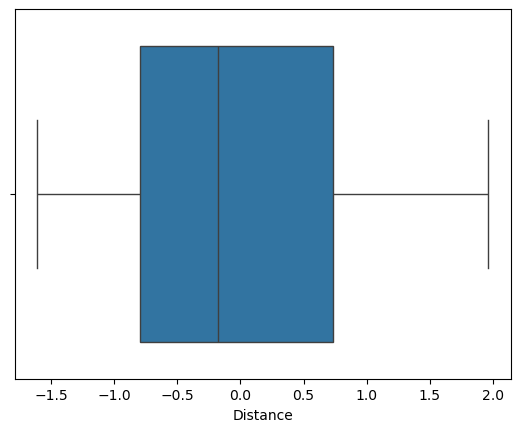

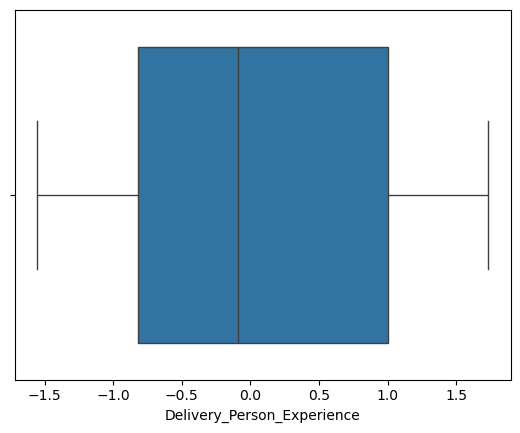

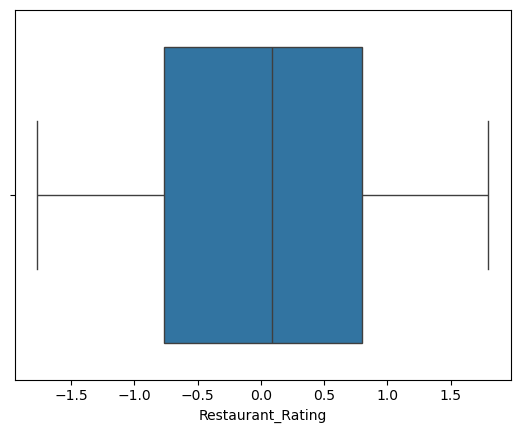

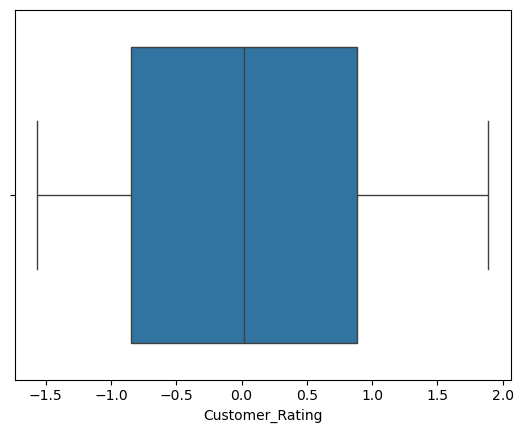

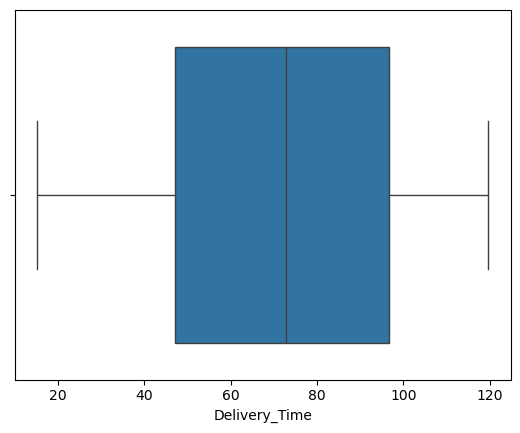

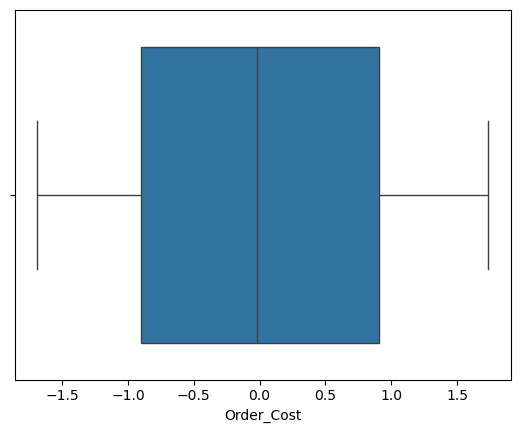

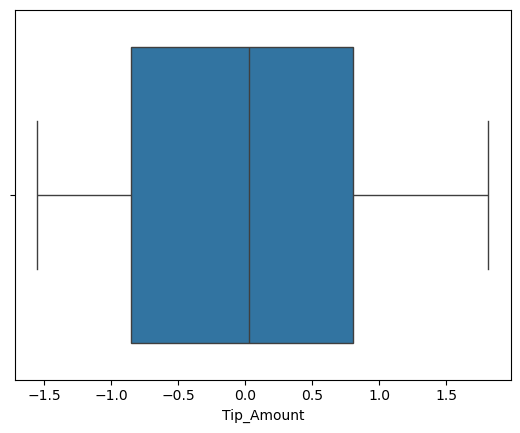

In [12]:
numeric_cols = data.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=data[col])
    plt.title
    plt.show()

In [13]:
from sklearn.model_selection import train_test_split

y= data['Delivery_Time']
x = data.drop('Delivery_Time', axis=1)

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [14]:
#model creation
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred = model.predict(x_test)

from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error 

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("MSE: ", mse,"\nr2: ",r2,"\nMAE: ", mae)

MSE:  1072.9744965019538 
r2:  -0.10117897034463263 
MAE:  27.931211313939333


In [16]:
#Logistic Regression Model building

#creating target column
data['Delivery_Status']= data['Delivery_Time'].apply(lambda x: 1 if x>60 else 0)

In [18]:
x1 = data.drop(['Delivery_Time','Delivery_Status'],axis=1)
y1=data['Delivery_Status']

x_train1,x_test1,y_train1,y_test1 =train_test_split(x1,y1,test_size =0.2)

#model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train1,y_train1)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
y_predict = model.predict(x_test1)

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

print("Accuracy:", accuracy_score(y_test1,y_predict))
print("Precision:", precision_score(y_test1,y_predict))
print("Recall:", recall_score(y_test1,y_predict))
print("F1 Score:", f1_score(y_test1,y_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test1,y_predict))

Accuracy: 0.55
Precision: 0.6111111111111112
Recall: 0.8461538461538461
F1 Score: 0.7096774193548387
Confusion Matrix:
 [[ 0 14]
 [ 4 22]]


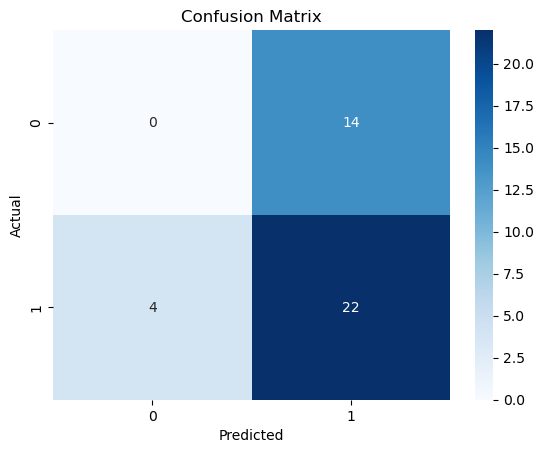

In [23]:
#confusion matrix

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test1,y_predict)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()